# CaSR v3.2 → Vancouver training pair

Pulls **CaSR v3.2 daily** near-surface air temperature over **Vancouver**, for
**2015-01-01 to 2018-01-01**, via OPeNDAP (nothing downloads until we crop + load).
Then coarsens the fine field to make a paired coarse input, and writes the same
`.npz` format `unet_semivariogram_experiment.ipynb` already reads.

Design choices baked in:
- **Crop before load.** The dataset is the whole North-American domain; we subset to
  Vancouver on the 2D `lat`/`lon` fields *first*, so only the small slice transfers.
- **Rotated grid.** CaSR is on a Lambert-Conformal grid indexed by `rlon`/`rlat`, so we
  crop with a boolean mask on the 2D `lat`/`lon` coordinates, not `.sel(lon=...)`.
- **Auto-detect the temperature variable.** CaSR uses coded names; we find the
  air-temperature variable by CF metadata / units rather than hardcoding a guess.
- **Coarsen-onto-itself** to form the coarse input — one dataset, no cross-grid
  regridding. (Swap in ERA5 later if you want the true-downscaling pairing.)

## 0. Environment — install into *this* kernel

In [1]:
# Installs into the kernel actually running this notebook (avoids the
# "installed in another Python" trap). Run once; restart the kernel afterward.
import sys
!{sys.executable} -m pip install -q xarray pydap netcdf4 dask numpy

## 1. Open the dataset over OPeNDAP

In [2]:
import numpy as np
import xarray as xr

url = "https://pavics.ouranos.ca/twitcher/ows/proxy/thredds/dodsC/datasets/reanalyses/day_NAM_GovCan_CaSR_v32_1980-2024.ncml"

# Lazy open — metadata only, no data transferred yet.
ds = xr.open_dataset(url, engine="pydap",
                     chunks=dict(time=1461, rlon=50, rlat=50))
print(ds)

/Users/finntran/Library/r-miniconda-arm64/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/finntran/Library/r-miniconda-arm64/lib/python3.12/site-packages/pydap/handlers/dap.py:164: UserWarning: PyDAP was unable to determine the DAP protocol defaulting to DAP2. DAP2 is consider legacy and may result in slower responses. 
Consider replacing `http` in your `url` with either `dap2` or `dap4` to specify the DAP protocol (e.g. `dap2://<data_url>` or `dap4://<data_url>`).  For more 
information, go to https://www.opendap.org/faq-page.
  warnings.warn(


<xarray.Dataset> Size: 2TB
Dimensions:       (rlat: 778, rlon: 706, time: 16437)
Coordinates:
  * rlat          (rlat) float32 3kB -44.1 -44.01 -43.92 ... 25.65 25.74 25.83
  * rlon          (rlon) float32 3kB -35.4 -35.31 -35.22 ... 27.87 27.96 28.05
    lat           (rlat, rlon) float32 2MB dask.array<chunksize=(50, 50), meta=np.ndarray>
    lon           (rlat, rlon) float32 2MB dask.array<chunksize=(50, 50), meta=np.ndarray>
  * time          (time) datetime64[ns] 131kB 1980-01-01 ... 2024-12-31
    rotated_pole  int32 4B ...
Data variables: (12/47)
    orog          (rlat, rlon) float32 2MB dask.array<chunksize=(50, 50), meta=np.ndarray>
    sftgif        (rlat, rlon) float32 2MB dask.array<chunksize=(50, 50), meta=np.ndarray>
    sftlf         (rlat, rlon) float32 2MB dask.array<chunksize=(50, 50), meta=np.ndarray>
    sftlkf        (rlat, rlon) float32 2MB dask.array<chunksize=(50, 50), meta=np.ndarray>
    sftof         (rlat, rlon) float32 2MB dask.array<chunksize=(50, 50), m

## 2. Find the air-temperature variable

CaSR variable names are coded (e.g. something like `CaSR_v3.2_A_TT_1.5m`). Rather than
hardcode a guess, detect it: look for a variable whose `standard_name`/`long_name`
mentions air temperature, or whose units are Kelvin/Celsius. The cell prints what it
found so you can confirm — if it grabs the wrong one, set `TEMP_VAR` by hand.

In [3]:
def find_temperature_var(ds):
    """Return the name of the near-surface AIR temperature variable.
    Prefers 1.5 m / 2 m air temperature; avoids skin/surface ('skin', 'ground',
    'sea surface') temperatures."""
    candidates = []
    for name, da in ds.data_vars.items():
        attrs = {k: str(v).lower() for k, v in da.attrs.items()}
        blob = " ".join(attrs.values()) + " " + name.lower()
        units = attrs.get("units", "").lower()
        is_temp = ("temperature" in blob) or ("air_temperature" in blob) or ("_tt_" in name.lower()) or ("tt" == name.lower())
        is_kelvin_or_c = units in ("k", "kelvin", "degc", "celsius", "degrees_celsius", "degree_celsius", "c")
        if is_temp or is_kelvin_or_c:
            # score: prefer explicit air temp at a near-surface height, penalize skin/surface
            score = 0
            if "air_temperature" in blob: score += 3
            if "1.5" in blob or "2 m" in blob or "2m" in blob or "1.5m" in blob: score += 2
            if "temperature" in blob: score += 1
            if is_kelvin_or_c: score += 1
            if any(w in blob for w in ("skin", "ground", "soil", "sea surface", "surface temperature")): score -= 4
            candidates.append((score, name, units, attrs.get("long_name", attrs.get("standard_name", ""))))
    candidates.sort(reverse=True)
    if not candidates:
        raise ValueError("No temperature-like variable found. Inspect ds.data_vars manually.")
    print("Temperature candidates (best first):")
    for sc, name, units, desc in candidates:
        print(f"  score={sc:>2}  {name:40s} units={units!r:12s} {desc}")
    return candidates[0][1]

TEMP_VAR = find_temperature_var(ds)
print("\nUsing TEMP_VAR =", TEMP_VAR)
# If the auto-pick is wrong, override manually, e.g.:
# TEMP_VAR = "CaSR_v3.2_A_TT_1.5m"

Temperature candidates (best first):
  score= 7  tasmin                                   units='k'          1.5 metre temperature
  score= 7  tasmax                                   units='k'          1.5 metre temperature
  score= 7  tas                                      units='k'          1.5 metre temperature
  score= 5  tamin                                    units='k'          20 metre air temperature (height is approximate :  see description)
  score= 5  tamax                                    units='k'          20 metre air temperature (height is approximate :  see description)
  score= 5  ta                                       units='k'          20 metre air temperature (height is approximate :  see description)
  score= 4  tdpsmin                                  units='k'          1.5 metre dewpoint temperature
  score= 4  tdpsmax                                  units='k'          1.5 metre dewpoint temperature
  score= 4  tdps                                     un

## 3. Locate the coordinate fields

On a rotated grid the useful coordinates are 2D `lat`/`lon` arrays (dims `rlat`,`rlon`).
Find their names — they're usually called `lat`/`lon` but can vary.

In [4]:
def find_lat_lon(ds):
    lat = lon = None
    for cand in ("lat", "latitude", "nav_lat", "gridlat"):
        if cand in ds.coords or cand in ds.variables:
            lat = cand; break
    for cand in ("lon", "longitude", "nav_lon", "gridlon"):
        if cand in ds.coords or cand in ds.variables:
            lon = cand; break
    if lat is None or lon is None:
        raise ValueError(f"Couldn't find lat/lon. coords={list(ds.coords)}")
    return lat, lon

LAT, LON = find_lat_lon(ds)
lat2d = ds[LAT]
lon2d = ds[LON]
# CaSR lon may be 0..360; convert to -180..180 for city boxes stated in negative degrees.
lon2d_180 = ((lon2d + 180) % 360) - 180
print("lat name:", LAT, "| lon name:", LON)
print("lat range:", float(lat2d.min()), float(lat2d.max()))
print("lon range (-180..180):", float(lon2d_180.min()), float(lon2d_180.max()))

lat name: lat | lon name: lon
lat range: 7.553605556488037 84.07162475585938
lon range (-180..180): -179.9925079345703 179.99896240234375


## 4. Crop to Vancouver and the date window

Vancouver box `[N=49.5, W=-123.5, S=49.0, E=-122.5]` (covers the city plus Burnaby,
Richmond, the North Shore mountains, and the Strait of Georgia). Dates
2015-01-01 to 2018-01-01. We mask on the 2D lat/lon, then trim to the bounding
`rlat`/`rlon` index range so the result is a compact rectangle.

In [5]:
# --- config ---
CITY   = "vancouver"
NORTH, WEST, SOUTH, EAST = 49.5, -123.5, 49.0, -122.5
DATE0, DATE1 = "2015-01-01", "2018-01-01"   # end-exclusive slice below

# --- spatial mask on 2D lat/lon ---
mask = (lat2d >= SOUTH) & (lat2d <= NORTH) & (lon2d_180 >= WEST) & (lon2d_180 <= EAST)
# reduce mask to the bounding index box on rlat/rlon so we keep a rectangle
ij = np.argwhere(mask.values)
if ij.size == 0:
    raise ValueError("Empty crop — check the box and lon convention.")
r0, c0 = ij.min(axis=0)
r1, c1 = ij.max(axis=0) + 1
rlat_name, rlon_name = mask.dims  # (rlat, rlon) order

da = ds[TEMP_VAR].isel({rlat_name: slice(r0, r1), rlon_name: slice(c0, c1)})
da = da.sel(time=slice(DATE0, DATE1))
# drop the end date if present so the window is [2015-01-01, 2018-01-01)
da = da.where(da["time"] < np.datetime64(DATE1), drop=True)

print("cropped shape (time, rlat, rlon):", da.shape)
print("date span:", str(da.time.values[0])[:10], "→", str(da.time.values[-1])[:10])

cropped shape (time, rlat, rlon): (1096, 8, 9)
date span: 2015-01-01 → 2017-12-31


In [6]:
# Pull the small subset into memory (this is the only real transfer).
fine = da.load()
arr = fine.values.astype("float32")   # [T, H, W]
# Guard against all-NaN or missing tiles
print("fine array:", arr.shape, "| NaNs:", int(np.isnan(arr).sum()),
      "| units:", fine.attrs.get("units", "?"))

fine array: (1096, 8, 9) | NaNs: 0 | units: K


## 5. Make the coarse input by block-averaging

Coarsen the 10 km fine field by an integer factor to form the paired coarse grid.
Factor 3 ≈ 30 km, roughly matching ERA5's resolution and the ~3× downscaling factor.
This trims the field to a multiple of the factor first.

In [7]:
COARSE_FACTOR = 3

def block_average(field2d, f):
    H, W = field2d.shape
    H2, W2 = (H // f) * f, (W // f) * f
    return field2d[:H2, :W2].reshape(H2 // f, f, W2 // f, f).mean(axis=(1, 3))

# trim time-stack to a common H,W multiple of the factor
T, H, W = arr.shape
H2, W2 = (H // COARSE_FACTOR) * COARSE_FACTOR, (W // COARSE_FACTOR) * COARSE_FACTOR
fine_stack = arr[:, :H2, :W2]                                   # [T, H2, W2]
coarse_stack = np.stack([block_average(fine_stack[t], COARSE_FACTOR)
                         for t in range(T)])                    # [T, H2/f, W2/f]

print("fine_stack:  ", fine_stack.shape)
print("coarse_stack:", coarse_stack.shape)

fine_stack:   (1096, 6, 9)
coarse_stack: (1096, 2, 3)


## 6. Shape into the `.npz` your U-Net notebook reads

The experiment notebook expects `coarse_stacks [N, C, h, w]` and `fine_targets [N, H, W]`.
Each daily field is one sample; we add a channel dim of 1 to the coarse side (single
variable, single time-step — extend to a multi-day stack later if you want temporal
context).

In [8]:
coarse_stacks = coarse_stack[:, None, :, :].astype("float32")   # [N, 1, h, w]
fine_targets  = fine_stack.astype("float32")                    # [N, H, W]

out = f"casr_{CITY}_2015_2018.npz"
np.savez_compressed(
    out,
    coarse_stacks=coarse_stacks,
    fine_targets=fine_targets,
    coarse_factor=COARSE_FACTOR,
    temp_var=TEMP_VAR,
    box=np.array([NORTH, WEST, SOUTH, EAST], dtype="float32"),
    date0=DATE0, date1=DATE1,
)
print("wrote", out)
print("  coarse_stacks:", coarse_stacks.shape)
print("  fine_targets: ", fine_targets.shape)

wrote casr_vancouver_2015_2018.npz
  coarse_stacks: (1096, 1, 2, 3)
  fine_targets:  (1096, 6, 9)


## 7. Quick look (optional)

Sanity-check one day: coarse input beside fine target.

In [12]:
import sys
!{sys.executable} -m pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 15.7 MB/s  0:00:00 eta 0:00:01
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 18.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 19.5 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]


Matplotlib is building the font cache; this may take a moment.


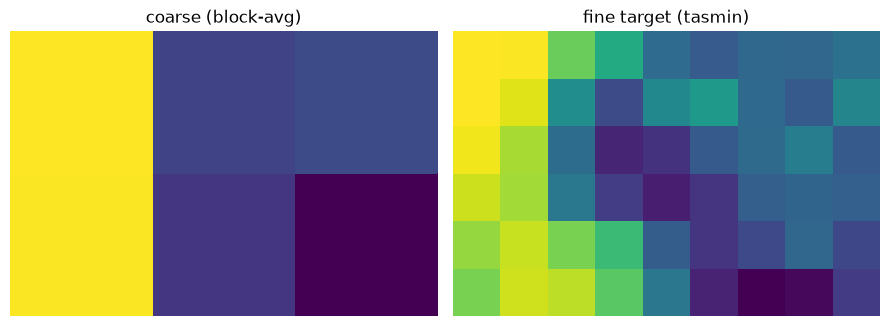

In [13]:
import matplotlib.pyplot as plt
t = 0
fig, ax = plt.subplots(1, 2, figsize=(9, 4))
ax[0].imshow(coarse_stacks[t, 0], origin="lower"); ax[0].set_title("coarse (block-avg)")
ax[1].imshow(fine_targets[t],    origin="lower"); ax[1].set_title(f"fine target ({TEMP_VAR})")
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()